Meta data propogated from the 1st original catalogue selection cuts and choices:
OrderedDict([('QEVOL_N', 0.78), ('ZMAX_N', 0.6), ('ZMIN_N', 0.002), ('BRIGHT_N', 10.0), ('FAINT_N', 19.54), ('AREA_N', 0.09278121822233744), ('F_RAN_N', 1.0), ('COL_N', 'blue'), ('STYLE_N', 'dashed'), ('QEVOL_S', 0.78), ('ZMAX_S', 0.6), ('ZMIN_S', 0.002), ('BRIGHT_S', 10.0), ('FAINT_S', 19.5), ('AREA_S', 0.2067143725378028), ('F_RAN_S', 1.0), ('COL_S', 'red'), ('STYLE_S', 'solid'), ('H0', 100.0), ('TCMB0', 2.725), ('OM0', 0.313), ('PMATCH', True), ('EXTNAME', 'SLICES')])
redshift cuts: zbin_edges
----------
     0.002
      0.05
       0.1
       0.2
       0.3
       0.4
       0.5
       0.6
Meta data propogated from the 2nd original catalogue selection cuts and choices:
OrderedDict([('QEVOL_N', 0.78), ('ZMAX_N', 0.1), ('ZMIN_N', 0.05), ('BRIGHT_N', 10.0), ('FAINT_N', 19.54), ('AREA_N', 0.09278121822233744), ('F_RAN_N', 1.0), ('COL_N', 'blue'), ('STYLE_N', 'dashed'), ('QEVOL_S', 0.78), ('ZMAX_S', 0.1), (

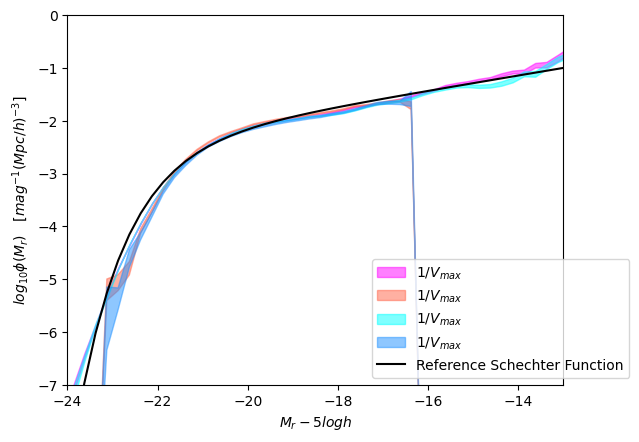

In [19]:
# Plot and manipulate the saved LFs from two sets of redshift slices
import matplotlib.pyplot as plt
import catalogue_analysis as ca
import numpy as np
from astropy.table import join,Table,Column,vstack
from astropy.io import fits

# Names of file containing LF estimates
LF1_FILE='LF_Y3_Sept2025_photounbiased.fits'

LF2_FILE='LF_Y3_Sept2025_photounbiased_z0p05to0p1.fits'


Plotslices = False

# Specify regions to loop over
regions=('S','N')

#First file
# Read the redshift bins 
SLICES= Table.read(LF1_FILE,hdu='SLICES')
zbin_edges=SLICES["zbin_edges"]
print("Meta data propogated from the 1st original catalogue selection cuts and choices:")
print(SLICES.meta)
print('redshift cuts:',zbin_edges)

# Read the redshift bins 
SLICES2= Table.read(LF2_FILE,hdu='SLICES')
zbin_edges2=SLICES2["zbin_edges"]
print("Meta data propogated from the 2nd original catalogue selection cuts and choices:")
print(SLICES2.meta)
print('redshift cuts:',zbin_edges2)


# Replot all the estimates
print('Plotting')

fig = plt.figure()         #defining so legend can be shifted  
ax = fig.add_subplot(111)



# Loop over regions
ireg = -1
col=('magenta','cyan') # colours for S and N overall 1/Vmax LFs
col2=('tomato','dodgerblue') # colours for S and N overall 1/Vmax LFs
colz=('red','blue') # colours for S and N redshift slices
colz2=('chocolate','purple') # colours for S and N redshift slices
for reg in regions:
    ireg += 1
    #Plot the overall 1/Vmax LF estimate
    LF=Table.read(LF1_FILE,hdu='LFVMAX'+reg)
    plt.fill_between(LF["magbins"],LF["log_phi_vmax_low"],LF["log_phi_vmax_hi"],color=col[ireg],alpha=0.5,label="$1/V_{max}$")
    #Plot the overall 1/Vmax LF estimate
    LF2=Table.read(LF2_FILE,hdu='LFVMAX'+reg)
    plt.fill_between(LF2["magbins"],LF2["log_phi_vmax_low"],LF2["log_phi_vmax_hi"],color=col2[ireg],alpha=0.5,label="$1/V_{max}$")


    #loop over redshift bins and overplot the estimates from each slice with no correction for (partially) empty bins
    if Plotslices:
        for jzbin in range(0,zbin_edges.size-1):  
            zlabel=f"Vol lim:{zbin_edges[jzbin]}<z<:{zbin_edges[jzbin+1]}"
            LF=Table.read(LF1_FILE,hdu='LFVLIM'+reg+str(jzbin))
            plt.fill_between(LF["magbins"],LF["log_phi_vmax_low"],LF["log_phi_vmax_hi"],color=colz[ireg],alpha=0.5,label=zlabel)
        for jzbin in range(0,zbin_edges2.size-1):  
            zlabel=f"Vol lim:{zbin_edges2[jzbin]}<z<:{zbin_edges2[jzbin+1]}"
            LF2=Table.read(LF2_FILE,hdu='LFVLIM'+reg+str(jzbin))
            plt.fill_between(LF2["magbins"],LF2["log_phi_vmax_low"],LF2["log_phi_vmax_hi"],color=colz2[ireg],alpha=0.5,label=zlabel)     


# Reference Schechter function from Sam's draft paper Table 1
phi_star=10.0**(-2.13)
alpha=-1.36
mstar=-21.10
l_lstar= 10.0**(0.4*(-LF["magbins"]+mstar))
phi_sch= phi_star * l_lstar**(1.0+alpha) * np.exp(-l_lstar) *(np.log(10.0)/2.5)
log_phi_sch = np.log10(phi_sch)
plt.plot(LF["magbins"],log_phi_sch, color='black',label='Reference Schechter Function')
plt.xlabel('$M_r - 5 log h$')
plt.ylabel('$log_{10} \phi(M_r)\quad  [mag^{-1} (Mpc/h)^{-3}]$')
plt.xlim([-24,-13])
plt.ylim([-7,0.0])
leg=plt.legend()

plt.draw() # Draw the figure so you can find the positon of the legend. 
# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(ax.transAxes.inverted()) 
# Change to location of the legend. 
xOffset = 0.6
bb.x0 += xOffset
bb.x1 += xOffset
leg.set_bbox_to_anchor(bb, transform = ax.transAxes)
plt.show()



Replotting with boosts and shifts for incomplete bins


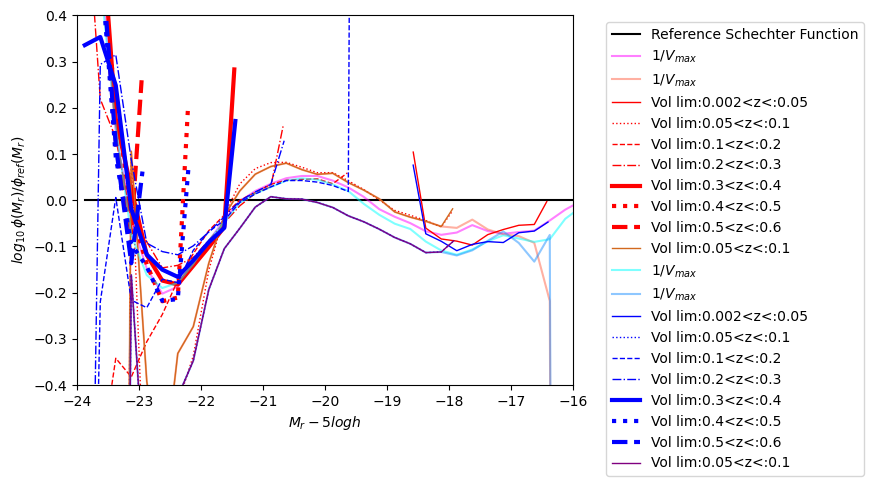

In [29]:
# Replot all the estimates without errors but with corrections for partially empty bins
print('Replotting with boosts and shifts for incomplete bins')
fig = plt.figure()         #defining so legend can be shifted  
ax = fig.add_subplot(111)

ratio = True
errors = False
Plotslices = True
# Reference Schechter function from Sam's draft paper Table 1
if (ratio==False): plt.plot(LF["magbins"],log_phi_sch, label='Reference Schechter Function',color='black')
if (ratio==True): plt.plot(LF["magbins"],log_phi_sch*0.0, label='Reference Schechter Function',color='black')

dmag=LF["magbins"][1]-LF["magbins"][0] # magnitude bin spacing
ireg = -1
col=('magenta','cyan') # colours for S and N overall 1/Vmax LFs
col2=('tomato','dodgerblue') # colours for S and N overall 1/Vmax LFs
colz=('red','blue') # colours for S and N redshift slices
colz2=('chocolate','purple') # colours for S and N redshift slices
style=('solid','dotted','dashed','dashdot','solid','dotted','dashed')
width=(1,1,1,1,3,3,3)
for reg in regions:
    ireg += 1
    # Replot the overall 1/Vmax LF estimate
    LF=Table.read(LF1_FILE,hdu='LFVMAX'+reg)
    LF2=Table.read(LF2_FILE,hdu='LFVMAX'+reg)
    if (ratio): 
        if (errors):
            plt.fill_between(LF["magbins"],LF["log_phi_vmax_low"]-log_phi_sch,LF["log_phi_vmax_hi"]-log_phi_sch,color=col[ireg],alpha=0.5,label="$1/V_{max}$")
        else:
            plt.plot(LF["magbins"],LF["log_phi_vmax"]-log_phi_sch,color=col[ireg],alpha=0.5,label="$1/V_{max}$")
    else:
        if (errors):
            plt.fill_between(LF["magbins"],LF["log_phi_vmax_low"],LF["log_phi_vmax_hi"],color=col[ireg],alpha=0.5,label="$1/V_{max}$")
        else:
            plt.plot(LF["magbins"],LF["log_phi_vmax"],color=col[ireg],alpha=0.5,label="$1/V_{max}$")
    # Repeat for 2nd file
    if (ratio):        
        if (errors):
            plt.fill_between(LF2["magbins"],LF2["log_phi_vmax_low"]-log_phi_sch,LF2["log_phi_vmax_hi"]-log_phi_sch,color=col2[ireg],alpha=0.5,label="$1/V_{max}$")
        else:
            plt.plot(LF2["magbins"],LF2["log_phi_vmax"]-log_phi_sch,color=col2[ireg],alpha=0.5,label="$1/V_{max}$")
    else:
        if (errors):
            plt.fill_between(LF2["magbins"],LF2["log_phi_vmax_low"],LF2["log_phi_vmax_hi"],color=col2[ireg],alpha=0.5,label="$1/V_{max}$")
        else:
            plt.plot(LF2["magbins"],LF2["log_phi_vmax"],color=col2[ireg],alpha=0.5,label="$1/V_{max}$")


        
    # Read the faint and bright absolute magnitude bounds for this region
    BOUNDS=Table.read(LF_FILE,hdu='BOUNDS_'+reg)
    BOUNDS2=Table.read(LF2_FILE,hdu='BOUNDS_'+reg)

    if Plotslices:
        # loop over redshift bins

        #First for file 1
        for jzbin in range(0,zbin_edges.size-1):  
            zlabel=f"Vol lim:{zbin_edges[jzbin]}<z<:{zbin_edges[jzbin+1]}"
            LF=Table.read(LF_FILE,hdu='LFVLIM'+reg+str(jzbin))

        
            # Determine completeness of each magnitude bin from the bounding absolute magnitudes of this redshift slice

            maghi=np.clip(LF["magbins"]+0.5*dmag,-100.0,BOUNDS["faint"][jzbin]) # hi-edge of occupied portion of the bin
            maglo=np.clip(LF["magbins"]-0.5*dmag,BOUNDS["bright"][jzbin],100.0) # lo-edge of occupied portion of the bin
            compl=np.clip((maghi-maglo)/dmag,0.0,1.0) #fraction of the bin occupied
      
            magbins_shifted=np.copy(LF["magbins"])
            notcomplete=(compl<1.0) & (compl>0.0)
            magbins_shifted[notcomplete]=0.5*(maghi[notcomplete]+maglo[notcomplete]) # just shift the partially complete bins
       
            magbinshifts=(LF["magbins"]-magbins_shifted)/dmag
            # mask empty bins and don't plot them  
            mask=compl>0.0
            #print('magbinshifts [in fractions of a bin]',magbinshifts[mask])   
            #print('boosts:',-np.log10(compl[mask]))
        
            if (ratio): 
                log_phi_sch_interp = np.interp(magbins_shifted, LF["magbins"], log_phi_sch) #log_phi_sch_interp=log_phi_sch # interpolate to the shifted bins 
                if (errors):
                    plt.fill_between(magbins_shifted[mask],LF["log_phi_vmax_low"][mask]-np.log10(compl[mask])-log_phi_sch_interp[mask],\
                                 LF["log_phi_vmax_hi"][mask]-np.log10(compl[mask])-log_phi_sch_interp[mask],color=colz[ireg],alpha=0.2)
                    plt.plot(magbins_shifted[mask],LF["log_phi_vmax"][mask]-np.log10(compl[mask])-log_phi_sch_interp[mask],color=colz[ireg],label=zlabel,linestyle=style[jzbin],linewidth=width[jzbin])
                else:
                    plt.plot(magbins_shifted[mask],LF["log_phi_vmax"][mask]-np.log10(compl[mask])-log_phi_sch_interp[mask],color=colz[ireg],label=zlabel,linestyle=style[jzbin],linewidth=width[jzbin])
            else:
                 if (errors):
                    plt.fill_between(magbins_shifted[mask],LF["log_phi_vmax_low"][mask]-np.log10(compl[mask]),\
                                 LF["log_phi_vmax_hi"][mask]-np.log10(compl[mask]),color=colz[ireg],alpha=0.5,label=zlabel,linestyle=style[jzbin])
                 else:
                    plt.plot(magbins_shifted[mask],LF["log_phi_vmax"][mask]-np.log10(compl[mask]),color=colz[ireg],alpha=0.5,label=zlabel,linestyle=style[jzbin])
        #Second for file 2
        for jzbin in range(0,zbin_edges2.size-1):  
            zlabel=f"Vol lim:{zbin_edges2[jzbin]}<z<:{zbin_edges2[jzbin+1]}"
            LF2=Table.read(LF2_FILE,hdu='LFVLIM'+reg+str(jzbin))

        
            # Determine completeness of each magnitude bin from the bounding absolute magnitudes of this redshift slice

            maghi=np.clip(LF2["magbins"]+0.5*dmag,-100.0,BOUNDS2["faint"][jzbin]) # hi-edge of occupied portion of the bin
            maglo=np.clip(LF2["magbins"]-0.5*dmag,BOUNDS2["bright"][jzbin],100.0) # lo-edge of occupied portion of the bin
            compl=np.clip((maghi-maglo)/dmag,0.0,1.0) #fraction of the bin occupied
      
            magbins_shifted=np.copy(LF2["magbins"])
            notcomplete=(compl<1.0) & (compl>0.0)
            magbins_shifted[notcomplete]=0.5*(maghi[notcomplete]+maglo[notcomplete]) # just shift the partially complete bins
       
            magbinshifts=(LF2["magbins"]-magbins_shifted)/dmag
            # mask empty bins and don't plot them  
            mask=compl>0.0
            #print('magbinshifts [in fractions of a bin]',magbinshifts[mask])   
            #print('boosts:',-np.log10(compl[mask]))
        
            if (ratio): 
                log_phi_sch_interp = np.interp(magbins_shifted, LF2["magbins"], log_phi_sch) #log_phi_sch_interp=log_phi_sch # interpolate to the shifted bins 
                if (errors):
                    plt.fill_between(magbins_shifted[mask],LF2["log_phi_vmax_low"][mask]-np.log10(compl[mask])-log_phi_sch_interp[mask],\
                                 LF2["log_phi_vmax_hi"][mask]-np.log10(compl[mask])-log_phi_sch_interp[mask],color=colz2[ireg],alpha=0.2)
                    plt.plot(magbins_shifted[mask],LF2["log_phi_vmax"][mask]-np.log10(compl[mask])-log_phi_sch_interp[mask],color=colz2[ireg],label=zlabel,linestyle=style[jzbin],linewidth=width[jzbin])
                else:
                    plt.plot(magbins_shifted[mask],LF2["log_phi_vmax"][mask]-np.log10(compl[mask])-log_phi_sch_interp[mask],color=colz2[ireg],label=zlabel,linestyle=style[jzbin],linewidth=width[jzbin])
            else:
                 if (errors):
                    plt.fill_between(magbins_shifted[mask],LF2["log_phi_vmax_low"][mask]-np.log10(compl[mask]),\
                                 LF2["log_phi_vmax_hi"][mask]-np.log10(compl[mask]),color=colz2[ireg],alpha=0.5,label=zlabel,linestyle=style[jzbin])
                 else:
                    plt.plot(magbins_shifted[mask],LF2["log_phi_vmax"][mask]-np.log10(compl[mask]),color=colz2[ireg],alpha=0.5,label=zlabel,linestyle=style[jzbin])
  

plt.xlabel('$M_r - 5 log h$')


if (ratio):
    plt.ylim([-0.4,0.4])
    plt.xlim([-24,-16])
    plt.ylabel('$log_{10} \, \phi(M_r)/\phi_{ref}(M_r)$') 
else:
    plt.ylim([-7,0.0])
    plt.xlim([-24,-13])
    plt.ylabel('$log_{10} \phi(M_r)\quad  [mag^{-1} (Mpc/h)^{-3}]$')
leg=plt.legend()

plt.draw() # Draw the figure so you can find the positon of the legend. 
# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(ax.transAxes.inverted()) 
# Change to location of the legend. 
xOffset = 0.6
bb.x0 += xOffset
bb.x1 += xOffset
leg.set_bbox_to_anchor(bb, transform = ax.transAxes)
plt.show()